# Montana Cities Transportation and Walkability Analysis (PySpark)

This notebook uses PySpark to demonstrate big data processing and Spark ML modeling for Montana city transportation and walkability data.

## Goals
- Load and clean the dataset using Spark
- Use Spark ML to build a linear regression model
- Analyze relationships between emissions and walkability
- Produce reproducible results suitable for a final year big data project

## 1. Install and Import Dependencies

If running on Google Colab, uncomment the installation line.

In [1]:
# Install dependencies if needed in Colab
# !pip install pyspark pandas numpy matplotlib seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print('Dependencies imported successfully!')

Dependencies imported successfully!


## 2. Start Spark and Load Data

Initialize Spark and read data with Spark's distributed CSV reader.

In [18]:
# Start Spark session
spark = SparkSession.builder \
    .appName('MontanaWalkabilityAnalysis') \
    .config('spark.driver.memory', '2g') \
    .config('spark.sql.shuffle.partitions', '4') \
    .getOrCreate()

# Load the cleaned full city data using pandas first, then create Spark DataFrame
pandas_df = pd.read_csv('cleaned_full_city_data.csv')
spark_df = spark.createDataFrame(pandas_df)

# Filter to Montana cities only
spark_df = spark_df.filter(col('state_abbr') == 'MT')

print('Spark DataFrame loaded')
print('Record count:', spark_df.count())
print('Schema:')
spark_df.printSchema()

Spark DataFrame loaded
Record count: 129
Schema:
root
 |-- NAME: string (nullable = true)
 |-- NAMELSAD: string (nullable = true)
 |-- state_abbr: string (nullable = true)
 |-- city_id: long (nullable = true)
 |-- city_state_name: string (nullable = true)
 |-- population: double (nullable = true)
 |-- house_units: double (nullable = true)
 |-- miles_driven_pC: double (nullable = true)
 |-- agg_vehi_consum_pC: double (nullable = true)
 |-- gasoline_consume_pC: double (nullable = true)
 |-- diesel_consume_pC: double (nullable = true)
 |-- agg_vehi_emitGHG_pC: double (nullable = true)
 |-- agg_nonvehi_emitGHG_pC: double (nullable = true)
 |-- agg_combined_emitGHG_pC: double (nullable = true)
 |-- driveGasoline_emitGHG_pC: double (nullable = true)
 |-- driveDiesel_emitGHG_pC: double (nullable = true)
 |-- wlk_NatWalkInd_avg: double (nullable = true)
 |-- wlk_PeopleCounted: double (nullable = true)
 |-- wlk_Workers: double (nullable = true)
 |-- wlk_CountHU: double (nullable = true)
 |-- wl

In [17]:
# Download the data file from GitHub if not present
import os
if os.path.exists('cleaned_full_city_data.csv'):
    os.remove('cleaned_full_city_data.csv')
!wget -q https://raw.githubusercontent.com/dimputp1/montana-transportation-analysis/master/cleaned_full_city_data.csv
print('Downloaded file')

print('File exists:', os.path.exists('cleaned_full_city_data.csv'))
if os.path.exists('cleaned_full_city_data.csv'):
    print('File size:', os.path.getsize('cleaned_full_city_data.csv'))

Downloaded file
File exists: True
File size: 8792840


## 3. Data Cleaning with Spark

Clean invalid sentinel values and cast numeric columns for modeling.

In [19]:
# Replace invalid sentinel values with null
clean_df = spark_df.replace([-99999, -99998], [None, None])

numeric_cols = [
    'population', 'house_units', 'miles_driven_pC', 'agg_vehi_consum_pC',
    'gasoline_consume_pC', 'diesel_consume_pC', 'agg_vehi_emitGHG_pC',
    'agg_nonvehi_emitGHG_pC', 'agg_combined_emitGHG_pC', 'driveGasoline_emitGHG_pC',
    'driveDiesel_emitGHG_pC', 'wlk_NatWalkInd_avg', 'wlk_PeopleCounted',
    'wlk_Workers', 'wlk_CountHU', 'wlk_HH', 'wlk_D2A_EPHHM_avg',
    'wlk_D2B_E8MIXA_avg', 'wlk_D3B_avg', 'wlk_D4A_avg', 'wlk_D2A_Ranked_avg',
    'wlk_D2B_Ranked_avg', 'wlk_D3B_Ranked_avg', 'wlk_D4A_Ranked_avg'
]

for c in numeric_cols:
    clean_df = clean_df.withColumn(c, col(c).cast('double'))

clean_df = clean_df.na.drop(subset=['agg_combined_emitGHG_pC', 'miles_driven_pC', 'wlk_NatWalkInd_avg'])

print('Cleaned Spark DataFrame record count:', clean_df.count())
print('Null counts for numeric columns:')
for c in numeric_cols:
    null_count = clean_df.filter(col(c).isNull()).count()
    if null_count > 0:
        print(f'  {c}: {null_count}')

Cleaned Spark DataFrame record count: 129
Null counts for numeric columns:
  wlk_D4A_avg: 24


## 4. Exploratory Data Analysis

Convert the cleaned Spark dataset to pandas for plotting key distributions.

Basic statistics for selected variables:
         population  miles_driven_pC  agg_combined_emitGHG_pC  \
count    129.000000       129.000000               129.000000   
mean    3241.905210      4642.047926                 8.545888   
std    11967.423517      5093.638636                 5.660131   
min        0.027895      1328.607843                 2.049461   
25%        0.869310      2415.452302                 5.566777   
50%       48.345089      3403.808318                 6.813124   
75%     1169.741442      4816.357661                 9.539938   
max    95445.470466     44023.653846                47.900115   

       wlk_NatWalkInd_avg  
count          129.000000  
mean             7.613284  
std              2.581327  
min              2.166667  
25%              5.666667  
50%              7.333333  
75%              9.325084  
max             15.545409  


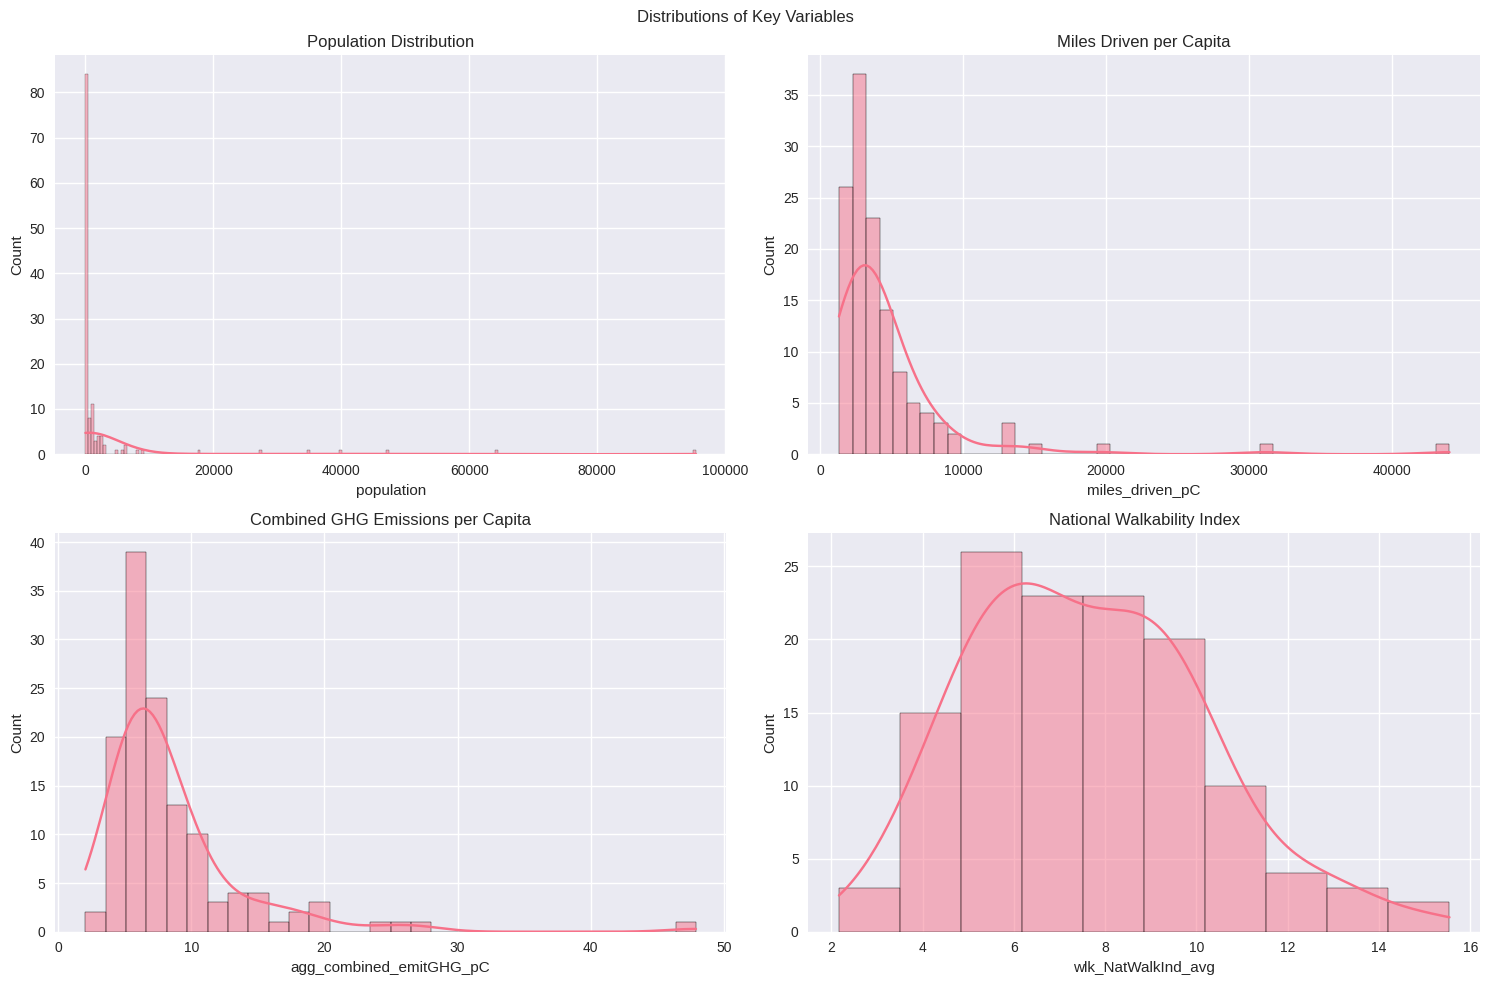

In [21]:
# Convert to pandas for visualization
pandas_df = clean_df.toPandas()

print('Basic statistics for selected variables:')
print(pandas_df[['population', 'miles_driven_pC', 'agg_combined_emitGHG_pC', 'wlk_NatWalkInd_avg']].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distributions of Key Variables')

sns.histplot(pandas_df['population'], ax=axes[0,0], kde=True)
axes[0,0].set_title('Population Distribution')

sns.histplot(pandas_df['miles_driven_pC'], ax=axes[0,1], kde=True)
axes[0,1].set_title('Miles Driven per Capita')

sns.histplot(pandas_df['agg_combined_emitGHG_pC'], ax=axes[1,0], kde=True)
axes[1,0].set_title('Combined GHG Emissions per Capita')

sns.histplot(pandas_df['wlk_NatWalkInd_avg'], ax=axes[1,1], kde=True)
axes[1,1].set_title('National Walkability Index')

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/pyspark_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

Understand how walkability and vehicle usage relate to emissions.

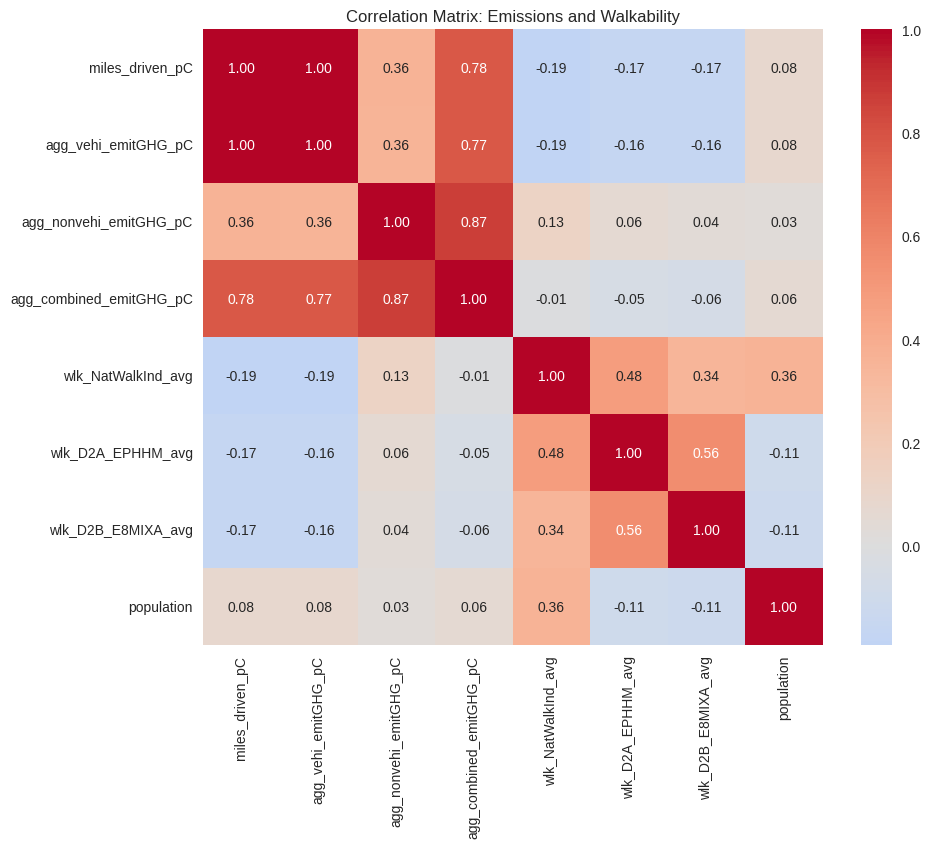

In [22]:
corr_cols = [
    'miles_driven_pC', 'agg_vehi_emitGHG_pC', 'agg_nonvehi_emitGHG_pC',
    'agg_combined_emitGHG_pC', 'wlk_NatWalkInd_avg', 'wlk_D2A_EPHHM_avg',
    'wlk_D2B_E8MIXA_avg', 'population'
]

corr_matrix = pandas_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: Emissions and Walkability')
plt.savefig('figures/pyspark_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

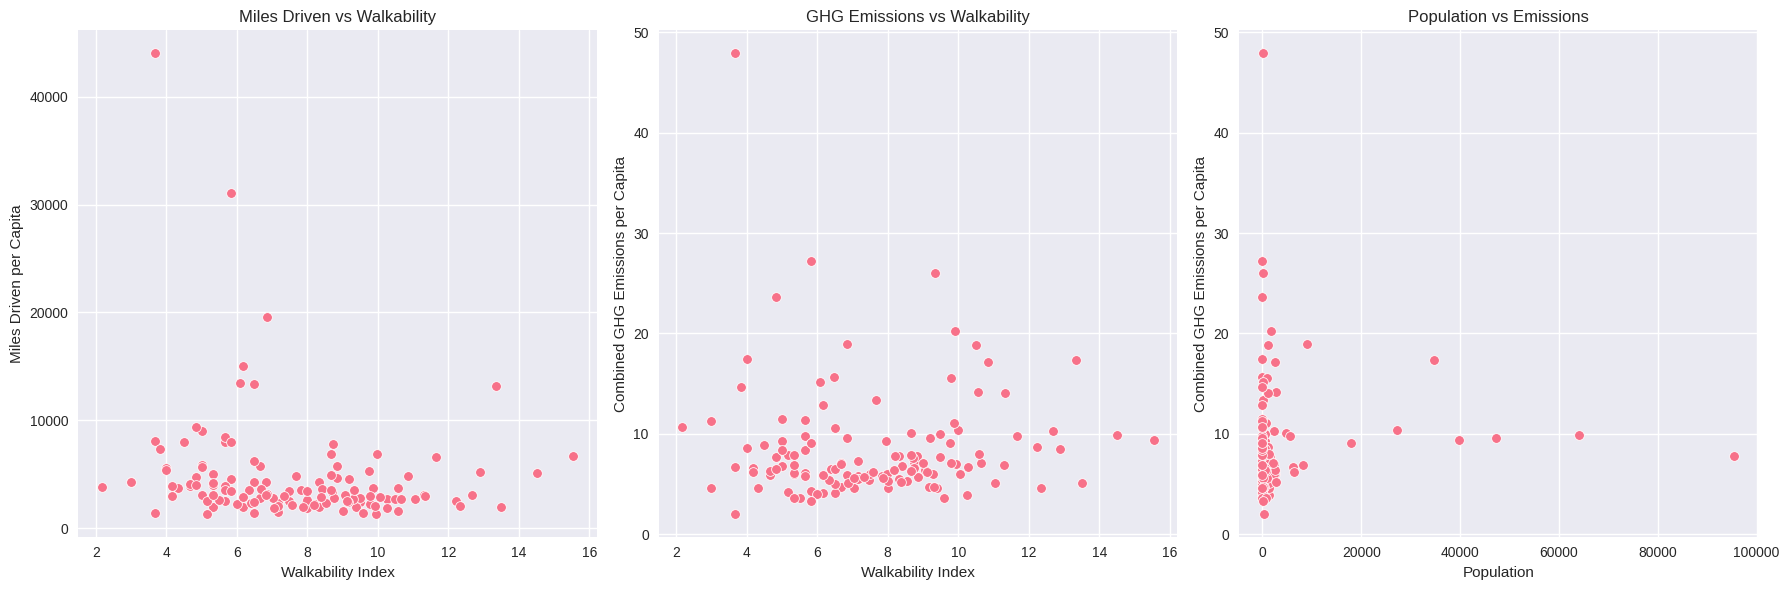

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.scatterplot(data=pandas_df, x='wlk_NatWalkInd_avg', y='miles_driven_pC', ax=axes[0])
axes[0].set_title('Miles Driven vs Walkability')
axes[0].set_xlabel('Walkability Index')
axes[0].set_ylabel('Miles Driven per Capita')

sns.scatterplot(data=pandas_df, x='wlk_NatWalkInd_avg', y='agg_combined_emitGHG_pC', ax=axes[1])
axes[1].set_title('GHG Emissions vs Walkability')
axes[1].set_xlabel('Walkability Index')
axes[1].set_ylabel('Combined GHG Emissions per Capita')

sns.scatterplot(data=pandas_df, x='population', y='agg_combined_emitGHG_pC', ax=axes[2])
axes[2].set_title('Population vs Emissions')
axes[2].set_xlabel('Population')
axes[2].set_ylabel('Combined GHG Emissions per Capita')

plt.tight_layout()
plt.savefig('figures/pyspark_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Spark ML Regression Model

Build a linear regression model in Spark to predict combined emissions per capita.

In [24]:
feature_cols = ['miles_driven_pC', 'wlk_NatWalkInd_avg', 'population']
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
model_df = assembler.transform(clean_df).select('features', 'agg_combined_emitGHG_pC')

train_df, test_df = model_df.randomSplit([0.75, 0.25], seed=42)

lr = LinearRegression(labelCol='agg_combined_emitGHG_pC', featuresCol='features')
lr_model = lr.fit(train_df)

print('Coefficients:', lr_model.coefficients)
print('Intercept:', lr_model.intercept)

predictions = lr_model.transform(test_df)
evaluator_rmse = RegressionEvaluator(labelCol='agg_combined_emitGHG_pC', predictionCol='prediction', metricName='rmse')
evaluator_r2 = RegressionEvaluator(labelCol='agg_combined_emitGHG_pC', predictionCol='prediction', metricName='r2')

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
print(f'RMSE: {rmse:.4f}')
print(f'R2: {r2:.4f}')

predictions.select('prediction', 'agg_combined_emitGHG_pC', 'features').show(10, truncate=False)

Coefficients: [0.0009183982446115561,0.4321867954576372,-4.2515009764931636e-05]
Intercept: 1.5285990202749797
RMSE: 2.4557
R2: -0.3590
+------------------+-----------------------+----------------------------------------------------------+
|prediction        |agg_combined_emitGHG_pC|features                                                  |
+------------------+-----------------------+----------------------------------------------------------+
|5.605477762059901 |4.071938188057522      |[1381.2223926380368,6.499999999999999,19.93765287491356]  |
|6.797796144824191 |7.085891564753005      |[1557.1298801700812,9.009487218878542,1285.4197653255417] |
|6.183206411220619 |5.829743040309732      |[1696.256170212766,7.166666666666667,13.407005482797237]  |
|7.567261874668193 |3.8868616934334814     |[1815.684003496504,10.249253472076765,1374.8123648648389] |
|9.088758526486236 |5.0621982394409        |[1939.849755035384,13.499121728179915,1306.2978257586076] |
|8.683130958587245 |4.6157644740

## 7. Model Interpretation

Review model coefficients and the actionable insights for city planning.

In [25]:
coefficients = list(lr_model.coefficients)
print('Model coefficients for features:')
for feature, coeff in zip(feature_cols, coefficients):
    print(f'  {feature}: {coeff:.4f}')

print('\nKey interpretation:')
print('- Higher miles driven per capita is associated with higher emissions.')
print('- Better walkability tends to relate to lower emissions.')
print('- City population also contributes to overall emissions intensity.')

Model coefficients for features:
  miles_driven_pC: 0.0009
  wlk_NatWalkInd_avg: 0.4322
  population: -0.0000

Key interpretation:
- Higher miles driven per capita is associated with higher emissions.
- Better walkability tends to relate to lower emissions.
- City population also contributes to overall emissions intensity.


## 8. Save Cleaned Data and Results

Persist cleaned data in Parquet format for scalable reuse.

In [26]:
clean_df.write.mode('overwrite').parquet('processed_city_data.parquet')

print('Saved cleaned data to processed_city_data.parquet')

spark.stop()
print('Spark session stopped. Analysis complete.')

Saved cleaned data to processed_city_data.parquet
Spark session stopped. Analysis complete.
